# Nettoyage et Analyse Exploratoire des Données

## 1. Charger les données

- Importer les bibliothèques nécessaires
- Charger le dataset avec Pandas
- Examiner les types de données et dimensions
- Afficher les statistiques descriptives

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/sample_data/Diabete.csv')

df.head()
df.drop('Unnamed: 0', axis=1, inplace=True)


In [108]:
df.shape

(768, 8)

In [109]:
df.dtypes

,0
Pregnancies,int64
Glucose,float64
BloodPressure,float64
SkinThickness,float64
Insulin,float64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 48.1 KB


In [111]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


## 2. Suppression des doublons

- Vérifier l’existence de doublons
- Supprimer les lignes dupliquées

In [112]:
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.duplicated().sum())

0
0


## 3. Gestion des valeurs manquantes

- Détecter les valeurs nulles
- Remplacer les valeurs manquantes
- Justifier la stratégie choisie

In [113]:
# Valeurs manquantes
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0


In [114]:
#calcul de pourcentage des nulls
df.isnull().mean().sort_values(ascending=False) * 100

,0
Insulin,48.697917
SkinThickness,29.557292
BloodPressure,4.557292
BMI,1.432292
Glucose,0.651042
Pregnancies,0.000000
DiabetesPedigreeFunction,0.000000
Age,0.000000


In [115]:
# Pour la collone Glucose, BMI  et BloodPressure c'est moins de 5% donc on peut remplacer les null par la médiane
for colonne in ["Glucose", "BMI", "BloodPressure"]:
    df[colonne] = df[colonne].fillna(df[colonne].median())

df.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,227
Insulin,374
BMI,0
DiabetesPedigreeFunction,0
Age,0


In [116]:
# Pour la collone insulin et SkinThickness c'est presque 50% donc on peut remplacer les null en utilisant knn
# avec features  "BMI", "Glucose", "Age", "SkinThickness"


from sklearn.impute import KNNImputer

cols = ["BMI", "Glucose", "Age", "SkinThickness", "Insulin","BloodPressure"]

imputer = KNNImputer(n_neighbors=5)
df[cols] = imputer.fit_transform(df[cols])

In [117]:
df.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0


## 4. Analyse exploratoire (EDA)

- Visualiser les variables numériques avec des histogrammes
- Détecter les outliers avec des boxplots
- Calculer la matrice de corrélation
- Interpréter les relations entre variables

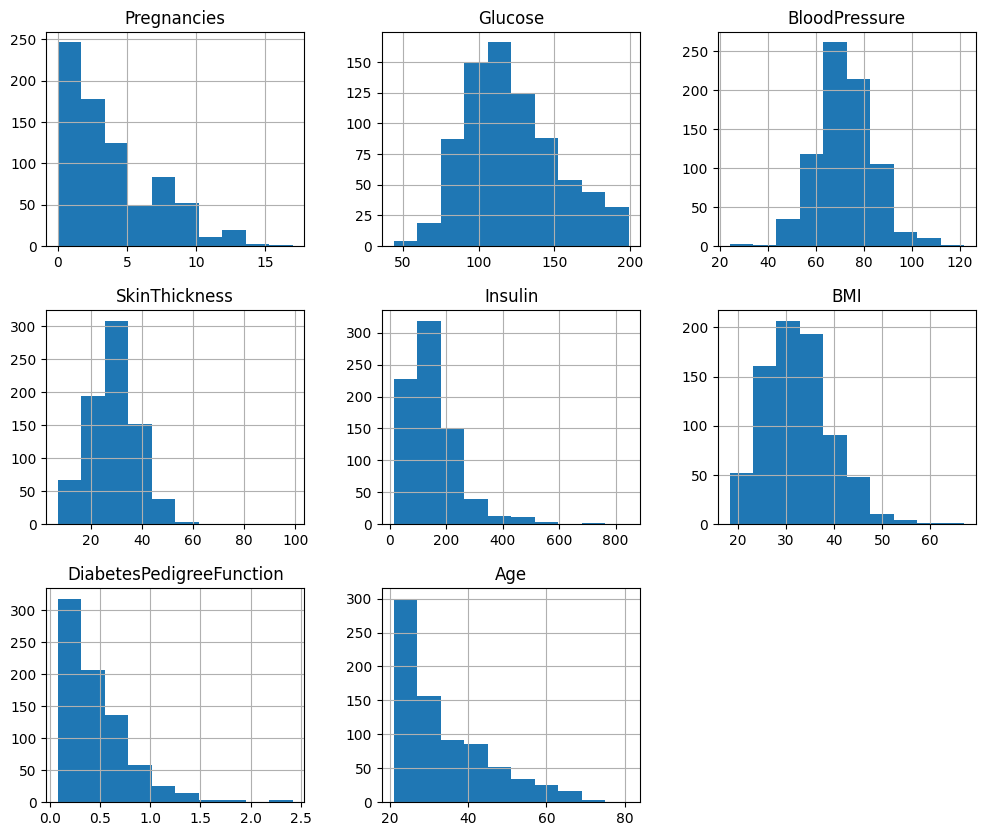

In [118]:
# Histogrammes
df.hist(figsize=(12,10))
plt.show()



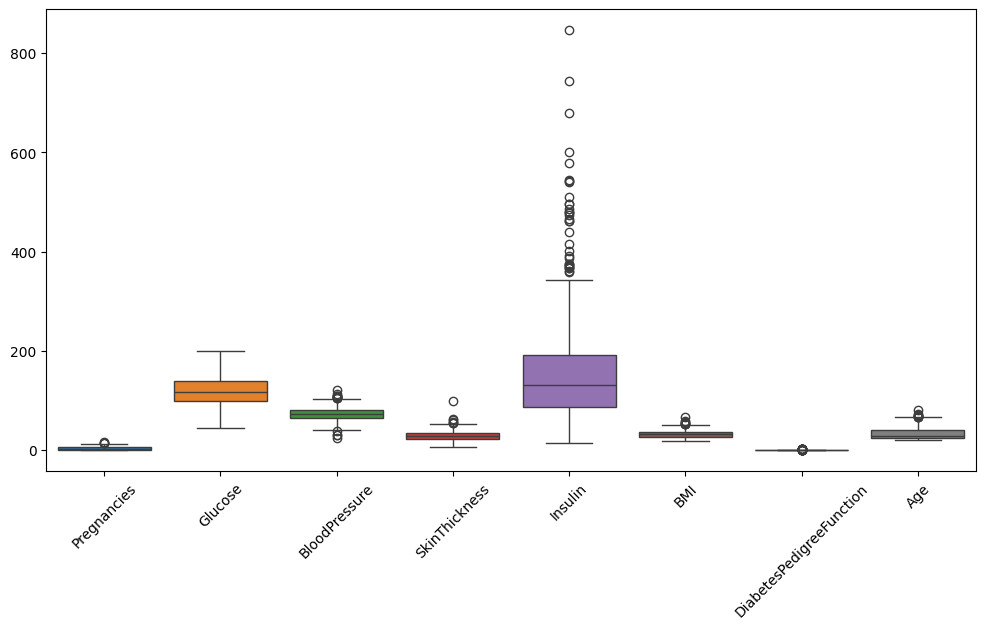

In [119]:
# Boxplots
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()



In [120]:
# Matrice de corrélation
correlation = df.corr(numeric_only=True)
print(correlation)


                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.128213       0.208615       0.101645   
Glucose                      0.128213  1.000000       0.218937       0.237371   
BloodPressure                0.208615  0.218937       1.000000       0.229061   
SkinThickness                0.101645  0.237371       0.229061       1.000000   
Insulin                      0.059866  0.626701       0.123812       0.249076   
BMI                          0.021559  0.231049       0.281257       0.637759   
DiabetesPedigreeFunction    -0.033523  0.137327      -0.002378       0.116367   
Age                          0.544341  0.266909       0.324915       0.155995   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.059866  0.021559                 -0.033523   
Glucose                   0.626701  0.231049                  0.137327   
BloodPressure             0.123812  0.281257    

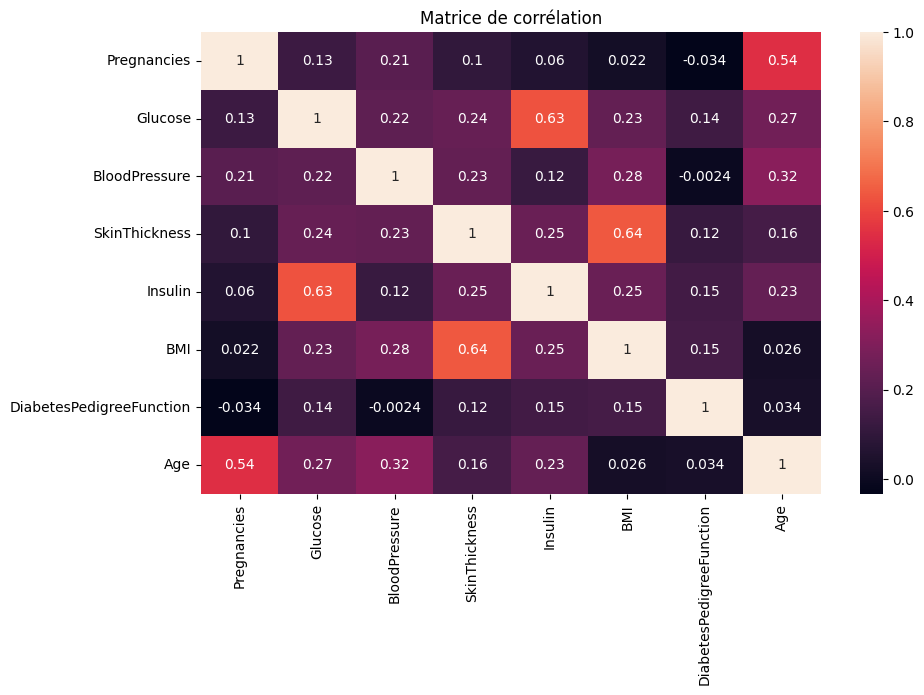

In [121]:
# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True)
plt.title('Matrice de corrélation')
plt.show()

## 5. Gestion des outliers

- Identifier les valeurs aberrantes avec la méthode IQR
- Supprimer ou traiter les outliers
- Justifier la stratégie choisie

(663, 8)


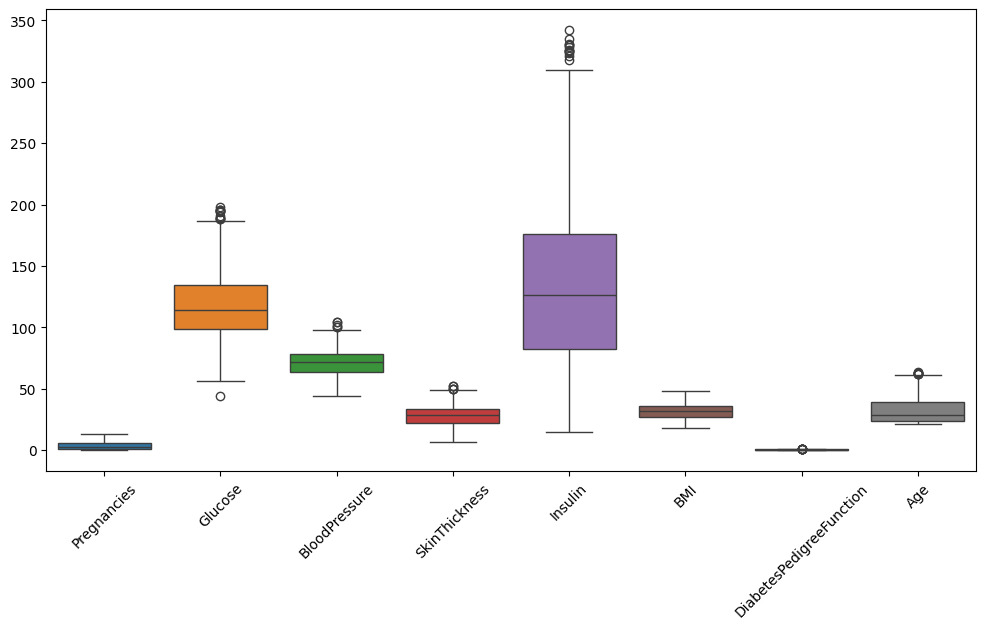

In [122]:
# Détection et suppression des outliers avec IQR
colonnes_numeriques = df.select_dtypes(include=np.number).columns

for colonne in colonnes_numeriques:
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1

    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    df = df[(df[colonne] >= borne_inf) & (df[colonne] <= borne_sup)]

# Dataset après suppression des outliers
print(df.shape)

# Visualisation après traitement
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()